In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
import random
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 50000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    

#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8


#graphe complet 
W3 = np.ones((a, a)) / a




### 1. on doit avoir un graphe non dirige 
# ici W3 (graphe fully connected) est non dirige --> agent i communqiue avec j et inversement 

###2. edges = aretes 
# les variables lambda_ij sont sur les aretes et on indexe ces aretes par j<i pour ne pas les compter deux fois 
# pour W3 : chaque noeud est connecte à tous les autres 
# l' ensemble E contient donc a(a-1)/2 paires 

### poids de Wij 
# ici il faut juste que nos poids soit positifs (presence d'une arete)
# ici avec W3, on a des Wii non nuls, il faudra donc les ignorer lors de la creation de lambda_ij car on regarde que i ~j ( i diff de j )







C:\Users\BONETTI\AppData\Local\Temp\ipykernel_13068\1251615862.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


**comparaison avec DGD et GT**

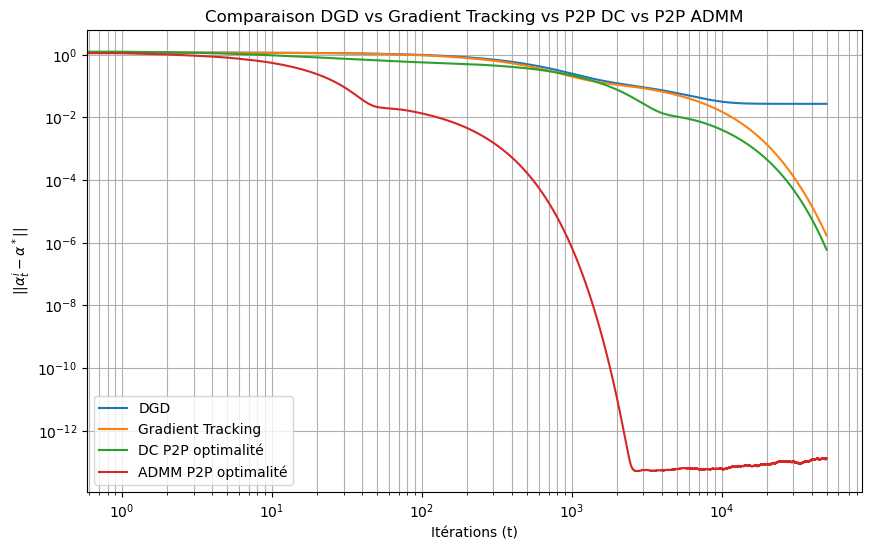

In [2]:
##### GT et DGD initialisation #######
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 




##### DC P2P initailisation ######""
# pour la partie initialisation : Initialize lambda_ij^0 for j < i" et interpret \lambda_ij for j > i as lambda_ji
lambdas = {}

for i in range(a):
    for j in range(a):
        if i > j and W3[i, j] > 0:
            lambdas[(i, j)] = np.zeros(m)
            
alpha_p2p= np.zeros((a,m)) # sequence des alpha necessaires pour le calcul

#pas 
eta=0.001
alpha_k=0.01




######### ADMM  ######
  
beta = 1.0
#beta=10
alpha_admm=np.zeros((a,m)) # sequence des alpha necessaires pour le calcul
lambdas_admm = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if W3[i,j] > 0 and i != j}
y_edges = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if W3[i,j] > 0 and i != j}








############## erreur pour chaque modèle ##########
erreur_p2p_optimalite=[]
erreur_p2p_consensus=[]
erreur_dgd=[]
erreur_gt=[]
erreur_admm_optimalite=[]
erreur_admm_consensus=[]

###################################################






# INITIALISATION GT et ADMM 
inv_Ai_admm = []
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
    
    ## ADMM
    di = np.sum(W3[i, :] > 0) - 1 # degré du nœud
    Ai = (sigma**2/a)*Kmm + Ki.T @ Ki + (nu/a)*np.eye(m) + beta * di * np.eye(m)
    inv_Ai_admm.append(np.linalg.inv(Ai))










for t in range (n_iter):
    
    
    
    ######### DGD ##########################
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    
    
    
    ########################### GT ##########################
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W3[i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W3[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    
    
    
    
    ####################### P2P 
    for i in range (a): #pour chaque agent 
        
        #ici on vient selectionner les données locales 
        #chaque agent traville sur son propre domaine de jeu de données : ici blocs de 20 points 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #somme dans le arg min 
        
        #calcul de la somme duale 
        dual_sum= np.zeros(m)
        for j in range(a):
            
            
            if W3[i, j] > 0 and i != j:
                if j <i :
                    dual_sum += lambdas[(i, j)]  # a=0, (-1)^0 = 1
                else:
                    dual_sum -= lambdas[(j, i)]  # a=1, (-1)^1 = -1
        
        #on cherche le point où la dérivée s'annule: derivée de fi(xi) 
        # ici c'est de la forme gradient = Ai * xi - bi 
        A_i= (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
        b_i= Ki.T @ yi - dual_sum
        alpha_p2p[i] = np.linalg.solve(A_i, b_i)
        
        
    # computation step des lambda (update for node i,j)
    for (i,j) in lambdas.keys(): # on a j<i 
        lambdas[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
        
    
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    # gap de consensus et non d'optimalité 
    mean_alpha = np.mean(alpha_p2p, axis=0)
    erreur_p2p_consensus.append(np.max([np.linalg.norm(alpha_p2p[i] - mean_alpha) for i in range(a)]))
    erreur_p2p_optimalite.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
    
    
    ###################### ADMM
    new_alpha_admm= np.zeros_like(alpha_admm)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        #terme de la somme sur i~j
        prox_sum= np.zeros(m)
        for j in range (a):
            if W3[i, j] > 0 and i != j:
                prox_sum =prox_sum  + y_edges[(i,j)] - (lambdas_admm[(i,j)] /beta)
        bi = Ki.T @ yi + beta*prox_sum 
        new_alpha_admm[i] = inv_Ai_admm[i] @ bi
    
    alpha_admm= new_alpha_admm
    # on doit aussi mettre à jour les lambdas et y 
    for i in range(a):
        for j in range(a):
            if W3[i, j] > 0 and i != j:
                y_edges[(i,j)]= (alpha_admm[i]+alpha_admm[j])/2
                lambdas_admm[(i,j)]= lambdas_admm[(i,j)] + beta * (alpha_admm[i] - y_edges[(i,j)])
    
    mean_alpha_admm = np.mean(alpha_admm, axis=0)
    erreur_admm_consensus.append(np.max([np.linalg.norm(alpha_admm[i] - mean_alpha_admm) for i in range(a)]))
    erreur_admm_optimalite.append(np.max([np.linalg.norm(alpha_admm[i] - alpha_star) for i in range(a)]))
    
        
   
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.loglog(erreur_p2p_optimalite, label='DC P2P optimalité')
plt.loglog(erreur_admm_optimalite, label='ADMM P2P optimalité')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking vs P2P DC vs P2P ADMM')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


        
    
    
   
    


**different graphs** 


In [2]:

#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    



In [3]:



#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8








In [21]:
def get_admm_errors(W_matrix):
    # --- Initialisation identique à ton code précédent ---
    alpha_admm = np.zeros((a, m))
    lambdas_admm = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if i != j and W_matrix[i, j] > 0}
    y_edges = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if i != j and W_matrix[i, j] > 0}
    
    erreur_admm_optimalite = []
    
    # Pré-calcul des inverses (spécifique à W_matrix)
    inv_Ai_admm = []
    for i in range(a):
        idx_loc = range(i*20, (i+1)*20)
        Ki, yi_loc = Knm[idx_loc, :], y[idx_loc]
        di = np.sum(W_matrix[i, :] > 0) - 1 
        Ai = (sigma**2/a)*Kmm + Ki.T @ Ki + (nu/a)*np.eye(m) + beta * di * np.eye(m)
        inv_Ai_admm.append(np.linalg.inv(Ai))

    # --- Boucle ADMM ---
    for t in range(n_iter):
        new_alpha_admm = np.zeros_like(alpha_admm)
        for i in range(a):
            prox_sum = np.zeros(m)
            for j in range(a):
                if i != j and W_matrix[i, j] > 0:
                    prox_sum += y_edges[(i, j)] - (lambdas_admm[(i, j)] / beta)
            
            idx_loc = range(i*20, (i+1)*20)
            bi = Knm[idx_loc, :].T @ y[idx_loc] + beta * prox_sum 
            new_alpha_admm[i] = inv_Ai_admm[i] @ bi
        
        alpha_admm = new_alpha_admm
        for (i, j) in lambdas_admm.keys():
            y_edges[(i, j)] = (alpha_admm[i] + alpha_admm[j]) / 2
            lambdas_admm[(i, j)] += beta * (alpha_admm[i] - y_edges[(i, j)])
        
        erreur_admm_optimalite.append(np.max([np.linalg.norm(alpha_admm[i] - alpha_star) for i in range(a)]))
        
    return erreur_admm_optimalite

In [24]:
def get_dgd_errors(W_matrix):
    # --- Initialisation identique à ton code précédent ---
    alpha_dgd = np.zeros((a, m))
    erreur_dgd = []

    for t in range (n_iter):

        ######### DGD ##########################
        #on fait les etapes pour DGD 
        new_alpha= np.zeros_like(alpha_dgd)
        for i in range (a): #pour chaque agent 
            idx_loc = range(i*20, (i+1)*20)
            Ki = Knm[idx_loc, :]
            yi = y[idx_loc]
            
            grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
            new_alpha[i] = W_matrix[i, :] @ alpha_dgd - eta * grad_i
        alpha_dgd= new_alpha
        
        erreur_dgd.append(np.max([np.linalg.norm(alpha_dgd[i] - alpha_star) for i in range(a)]))
        
    return erreur_dgd

Calcul pour le graphe Complet...
Calcul pour le graphe Cycle...
Calcul pour le graphe Ligne...


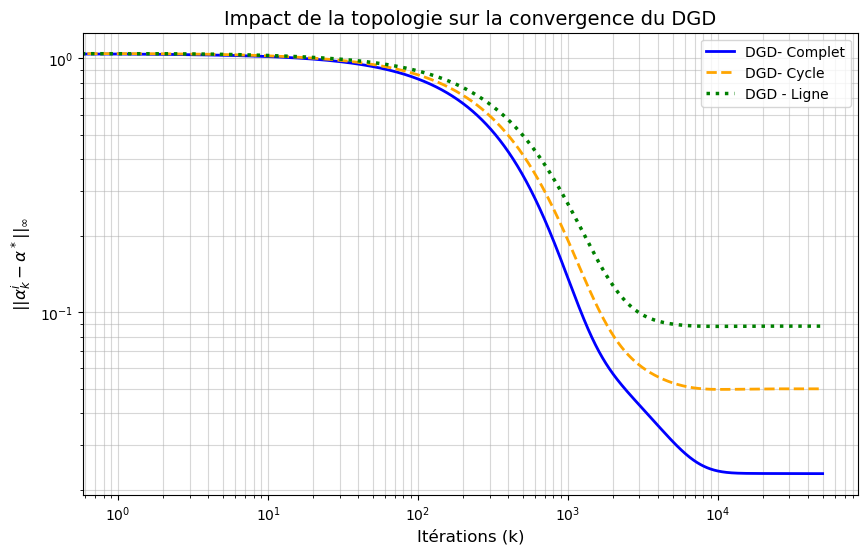

In [25]:
# 1. Calcul des erreurs pour chaque topologie
print("Calcul pour le graphe Complet...")
#err_complet = get_admm_errors(W3)
err_complet = get_dgd_errors(W3)

print("Calcul pour le graphe Cycle...")
#err_cycle = get_admm_errors(W)
err_cycle = get_dgd_errors(W)


print("Calcul pour le graphe Ligne...")
#err_ligne = get_admm_errors(W2)
err_ligne = get_dgd_errors(W2)


# 2. Affichage sur une seule figure
plt.figure(figsize=(10, 6))
plt.loglog(err_complet, label='DGD- Complet', color='blue', linewidth=2)
plt.loglog(err_cycle, label='DGD- Cycle', color='orange', linestyle='--', linewidth=2)
plt.loglog(err_ligne, label='DGD - Ligne', color='green', linestyle=':', linewidth=2.5)

plt.title('Impact de la topologie sur la convergence du DGD', fontsize=14)
plt.xlabel('Itérations (k)', fontsize=12)
plt.ylabel(r'$||\alpha_k^i - \alpha^*||_\infty$', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

**visualisation**

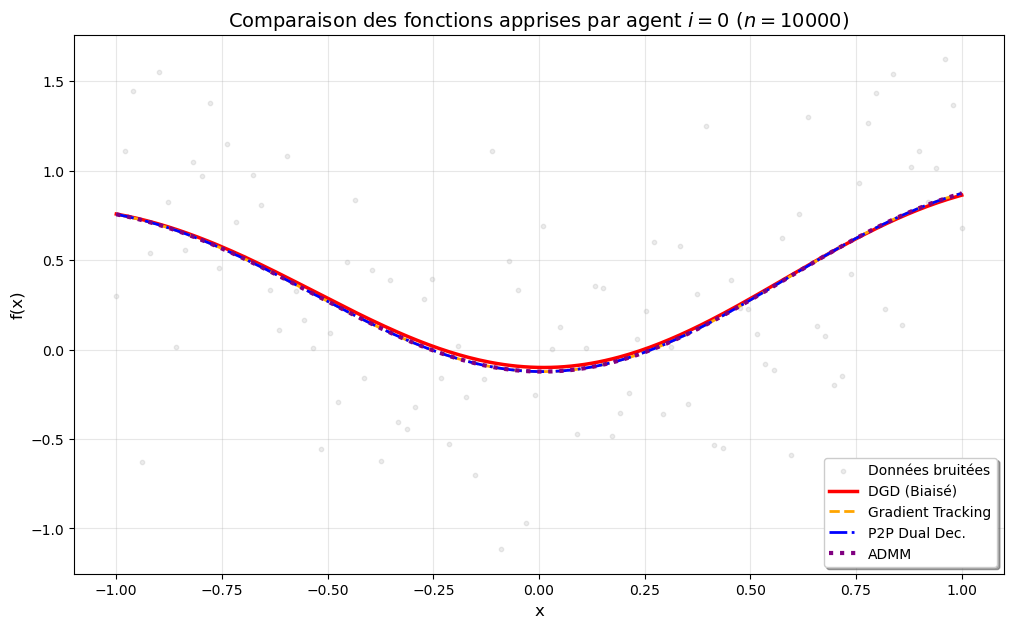

In [17]:
#visualisation de la fonction apprise 

nt = 250
x_prime = np.linspace(-1, 1, nt) # 
K_test = Cov2(x_prime, x_m) 

plt.figure(figsize=(12, 7))


plt.scatter(x, y, alpha=0.15, s=10, label='Données bruitées', color='gray')

# 2. Définition des styles pour différencier les courbes proches
# On utilise des styles de lignes différents (tirets, points) pour GT/ADMM/P2P
y_pred_dgd = K_test @ alpha_dgd[0] 
plt.plot(x_prime, y_pred_dgd, label='DGD (Biaisé)', color='red', linestyle='-', linewidth=2.5)

y_pred_gt = K_test @ alpha_gt[0] 
plt.plot(x_prime, y_pred_gt, label='Gradient Tracking', color='orange', linestyle='--', linewidth=2)

y_pred_p2p = K_test @ alpha_p2p[0] 
plt.plot(x_prime, y_pred_p2p, label='P2P Dual Dec.', color='blue', linestyle='-.', linewidth=2)

y_pred_admm = K_test @ alpha_admm[0] 
plt.plot(x_prime, y_pred_admm, label='ADMM', color='purple', linestyle=':', linewidth=3)

# 3. Cosmétique du graphique
plt.title(r"Comparaison des fonctions apprises par agent $i=0$ ($n=10000$)", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(alpha=0.3)


plt.show()

**rompre la convergence**


In [29]:
import random

def get_corrupted_context(W_base, mode='normal', p_loss=0.2, p_active=0.4):
    a = W_base.shape[0]
    W_t = W_base.copy()
    mask = [True] * a 
    
    if mode == 'directed':
        for i in range(a):
            for j in range(i + 1, a):
                if random.random() < 0.5: W_t[i, j] = 0 
                else: W_t[j, i] = 0 
                    
    elif mode == 'loss':
        for i in range(a):
            for j in range(a):
                if i != j and random.random() < p_loss: W_t[i, j] = 0
        # Renormalisation ligne par ligne pour la stochasticité à gauche
        for i in range(a):
            s = np.sum(W_t[i, :])
            if s > 0: W_t[i, :] /= s

    elif mode == 'async':
        mask = [random.random() < p_active for _ in range(a)]
        if not any(mask): mask[random.randint(0, a-1)] = True
        
    return W_t, mask

In [30]:
def test_break_convergence(mode='loss'):
    # --- Initialisations ---
    alpha_dgd = np.zeros((a, m))
    alpha_gt = np.zeros((a, m))
    g_gt = np.zeros((a, m))
    alpha_p2p = np.zeros((a, m))
    alpha_admm = np.zeros((a, m))
    
    # Dictionnaires pour P2P et ADMM (on utilise le graphe complet W3 comme base)
    lambdas_p2p = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if i > j and W3[i, j] > 0}
    lambdas_admm = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if i != j and W3[i, j] > 0}
    y_edges = {(i, j): np.zeros(m) for i in range(a) for j in range(a) if i != j and W3[i, j] > 0}

    # Hyperparamètres
    eta = 0.001
    alpha_k = 0.01 # Pas dual P2P
    beta = 1.0     # Paramètre ADMM

    # Erreurs
    err_dgd, err_gt, err_p2p, err_admm = [], [], [], []

    # --- Pré-calculs ---
    inv_Ai_admm = []
    for i in range(a):
        idx_loc = range(i*20, (i+1)*20)
        Ki, yi = Knm[idx_loc, :], y[idx_loc]
        # Initialisation g_gt
        g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # Inverses ADMM (basées sur le degré max pour être stable)
        di = np.sum(W3[i, :] > 0) - 1
        Ai = (sigma**2/a)*Kmm + Ki.T @ Ki + (nu/a)*np.eye(m) + beta * di * np.eye(m)
        inv_Ai_admm.append(np.linalg.inv(Ai))

    # --- Boucle temporelle ---
    for t in range(n_iter):
        # On génère la perturbation du tour t
        W_t, mask = get_corrupted_context(W3, mode=mode)

        new_alpha_dgd = alpha_dgd.copy()
        new_alpha_gt = alpha_gt.copy()
        new_g_gt = g_gt.copy()
        new_alpha_admm = alpha_admm.copy()

        for i in range(a):
            if mask[i]: # Si l'agent i est réveillé
                idx_loc = range(i*20, (i+1)*20)
                Ki, yi = Knm[idx_loc, :], y[idx_loc]
                
                # 1. DGD
                grad_i_dgd = (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
                new_alpha_dgd[i] = W_t[i, :] @ alpha_dgd - eta * grad_i_dgd

                # 2. GT
                grad_k = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
                new_alpha_gt[i] = W_t[i, :] @ alpha_gt - eta * g_gt[i]
                grad_k1 = (sigma**2/a) * Kmm @ new_alpha_gt[i] + Ki.T @ (Ki @ new_alpha_gt[i] - yi) + (nu/a) * new_alpha_gt[i]
                new_g_gt[i] = W_t[i, :] @ g_gt + (grad_k1 - grad_k)

                # 3. P2P Dual (Résolution exacte)
                dual_sum = np.zeros(m)
                for j in range(a):
                    if W_t[i, j] > 0 and i != j:
                        if i > j: dual_sum += lambdas_p2p[(i, j)]
                        else: dual_sum -= lambdas_p2p[(j, i)]
                Ai_p2p = (sigma**2/a) * Kmm + Ki.T @ Ki + (nu/a) * np.eye(m)
                bi_p2p = Ki.T @ yi - dual_sum
                alpha_p2p[i] = np.linalg.solve(Ai_p2p, bi_p2p)

                # 4. ADMM
                prox_sum = np.zeros(m)
                for j in range(a):
                    if W_t[i, j] > 0 and i != j:
                        prox_sum += y_edges[(i,j)] - (lambdas_admm[(i,j)] / beta)
                bi_admm = Ki.T @ yi + beta * prox_sum 
                new_alpha_admm[i] = inv_Ai_admm[i] @ bi_admm

        # --- Mises à jour globales ---
        alpha_dgd, alpha_gt, g_gt, alpha_admm = new_alpha_dgd, new_alpha_gt, new_g_gt, new_alpha_admm

        # Mise à jour des variables duales (Arêtes)
        for i in range(a):
            if mask[i]:
                # Dual P2P
                for j in range(a):
                    if i > j and W_t[i, j] > 0:
                        lambdas_p2p[(i, j)] += alpha_k * (alpha_p2p[i] - alpha_p2p[j])
                # ADMM
                for j in range(a):
                    if i != j and W_t[i, j] > 0:
                        y_edges[(i,j)] = (alpha_admm[i] + alpha_admm[j]) / 2
                        lambdas_admm[(i,j)] += beta * (alpha_admm[i] - y_edges[(i,j)])

        # --- Stockage des erreurs ---
        err_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))
        err_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
        err_p2p.append(np.max([np.linalg.norm(alpha_p2p[i] - alpha_star) for i in range(a)]))
        err_admm.append(np.max([np.linalg.norm(alpha_admm[i] - alpha_star) for i in range(a)]))

    return err_dgd, err_gt, err_p2p, err_admm

Simulation du scénario : normal...
Simulation du scénario : loss...
Simulation du scénario : directed...
Simulation du scénario : async...


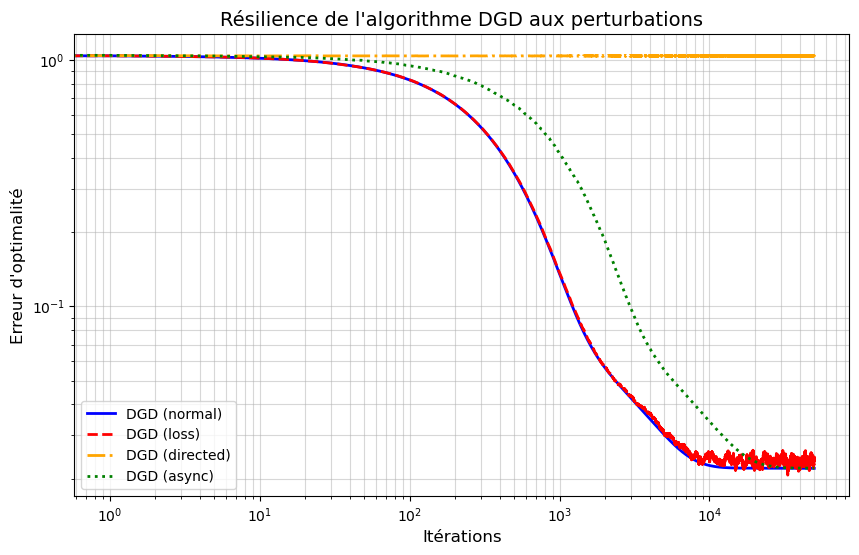

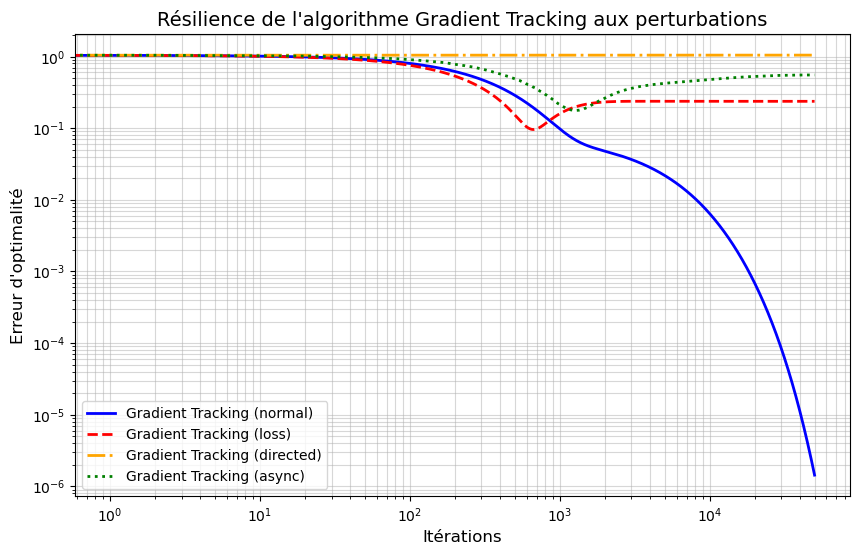

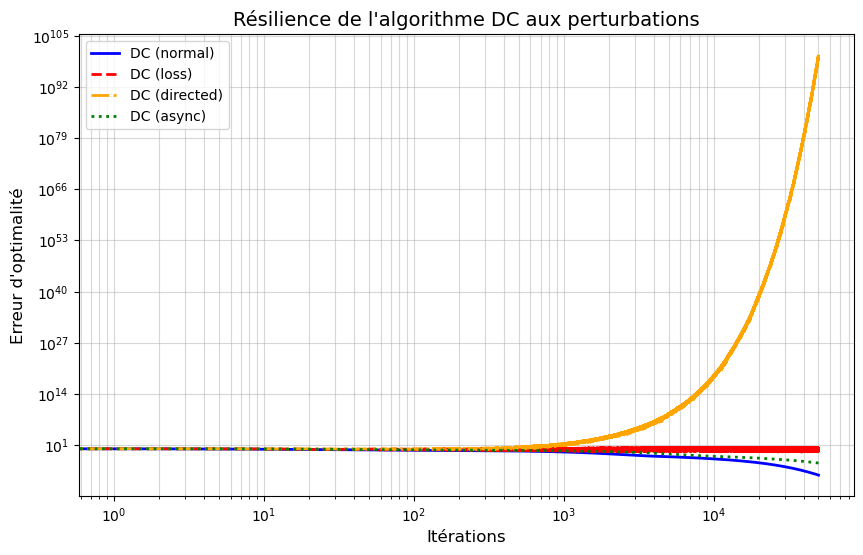

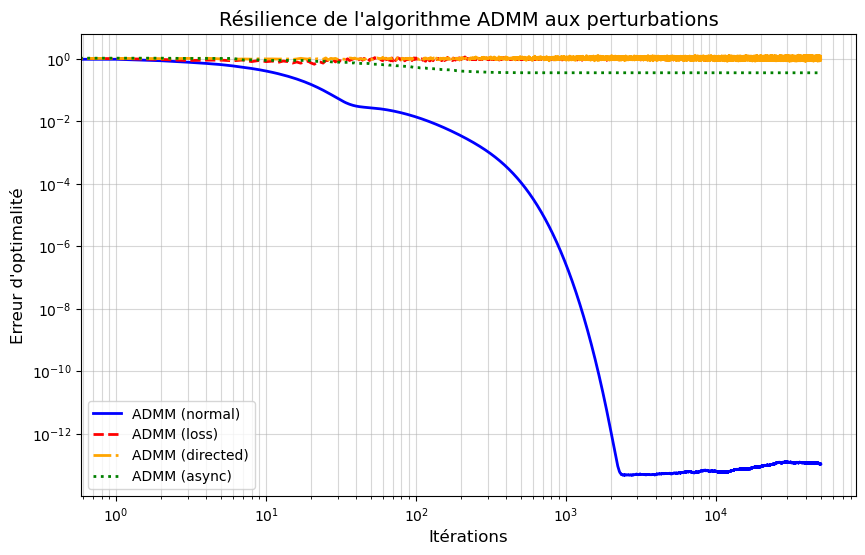

In [31]:
scenarios = ['normal', 'loss', 'directed', 'async']
results = {scen: None for scen in scenarios}

# On lance les simulations
for scen in scenarios:
    print(f"Simulation du scénario : {scen}...")
    results[scen] = test_break_convergence(mode=scen)
    
    
def plot_model_resilience(model_idx, model_name):
    plt.figure(figsize=(10, 6))
    colors = {'normal': 'blue', 'loss': 'red', 'directed': 'orange', 'async': 'green'}
    styles = {'normal': '-', 'loss': '--', 'directed': '-.', 'async': ':'}
    
    for scen in scenarios:
        # model_idx : 0=DGD, 1=GT, 2=P2P, 3=ADMM
        plt.loglog(results[scen][model_idx], 
                   label=f'{model_name} ({scen})', 
                   color=colors[scen], 
                   linestyle=styles[scen], 
                   linewidth=2)
    
    plt.title(f'Résilience de l\'algorithme {model_name} aux perturbations', fontsize=14)
    plt.xlabel('Itérations', fontsize=12)
    plt.ylabel('Erreur d\'optimalité', fontsize=12)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

# Affichage des graphiques pour chaque modèle
plot_model_resilience(0, "DGD")
plot_model_resilience(1, "Gradient Tracking")
plot_model_resilience(2, "DC")
plot_model_resilience(3, "ADMM")

# results[scen] contient maintenant (err_dgd, err_gt, err_p2p, err_admm)

**pushsum**


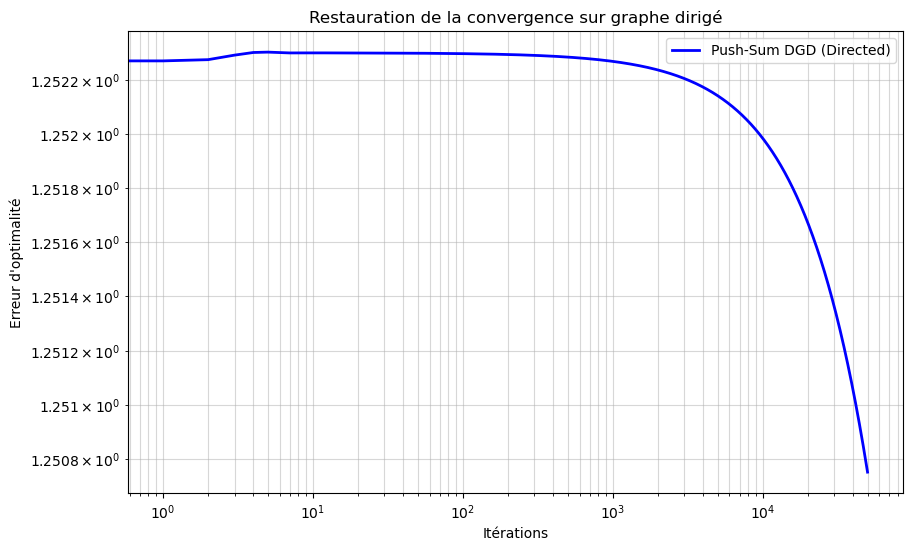

In [6]:

def run_push_sum_directed_small_n(
    W, n_iter, alpha_star,
    Knm, y, Kmm,
    sigma, nu,
    a, m, eta
):

    n = Knm.shape[0]
    n_i = n // a

    x = np.random.randn(a, m) * 1e-3
    phi = np.ones((a, 1))

    erreur = []

    # Pré-découpage local
    K_tensor = Knm.reshape(a, n_i, m)
    Y_tensor = y.reshape(a, n_i)

    reg = (sigma**2 / a) * Kmm + (nu / a) * np.eye(m)

    for k in range(n_iter):

        # --- Communication ---
        x = W @ x
        phi = W @ phi
        phi = np.clip(phi, 1e-12, None)

        z = x / phi

        # --- Gradient local vectorisé ---
        grad = (
            np.einsum('aij,aj->ai', 
                      np.matmul(K_tensor.transpose(0,2,1), K_tensor),
                      z)
            - np.matmul(K_tensor.transpose(0,2,1), Y_tensor[...,None]).squeeze(-1)
            + z @ reg.T
        )

        x = x - eta * grad

        z_mean = np.mean(x / phi, axis=0)
        erreur.append(np.linalg.norm(z_mean - alpha_star))

    return erreur


#matrice direcetd 


eta=1e-8

W_t=W3.copy()


seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)


for i in range(a):
    for j in range(i + 1, a):
            if random.random() < 0.5: W_t[i, j] = 0 
            else: W_t[j, i] = 0 
W_push = (W_t > 0).astype(float)
for i in range(a):
    W_push[i, i] = 1.0
W_push = W_push / W_push.sum(axis=0)
#print(f"Somme des colonnes (doit être 1.0) : {np.sum(W_push, axis=0)}")
err_push_sum = run_push_sum_directed_small_n(W_push, n_iter, alpha_star, Knm, y, Kmm, sigma, nu, a, m, eta)

# Visualisation
plt.figure(figsize=(10, 6))
plt.loglog(err_push_sum, label='Push-Sum DGD (Directed)', color='blue', linewidth=2)
plt.title("Restauration de la convergence sur graphe dirigé")
plt.xlabel("Itérations")
plt.ylabel("Erreur d'optimalité")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

si on augmente n 

Calcul en cours pour n=100000...


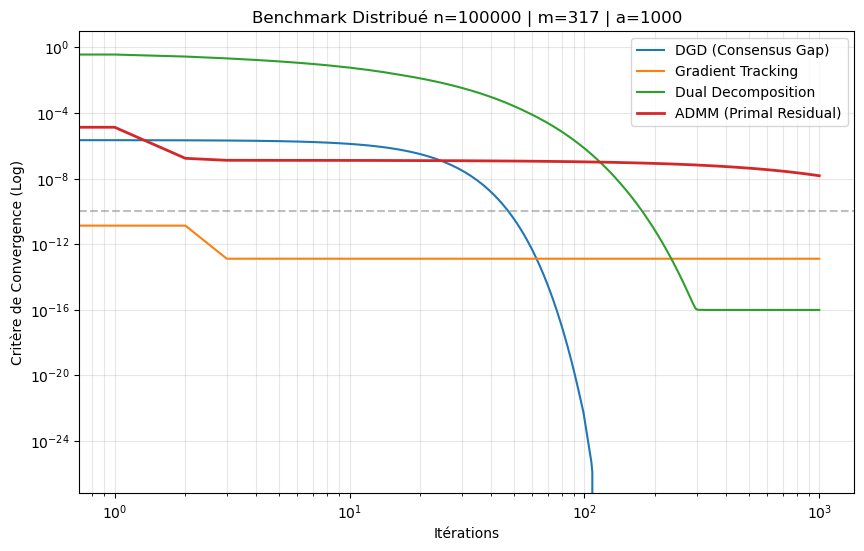

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# --- 1. CONFIGURATION ÉLEVÉE ---
n = 100000
m = int(np.ceil(np.sqrt(n)))
a = 1000  # Nombre d'agents
n_i = n // a
n_iter = 1000

sigma, nu = 0.5, 1.0
eta_dgd = 1e-3  # Pas pour DGD
eta_gt = 1e-3   # Pas pour GT
rho_dc = 1e-3   # Pas dual pour DC
beta_admm = 1.0 # Pénalité ADMM

# --- 2. PRÉPARATION DES DONNÉES (Simulation ou Chargement) ---
# Remplacer par ton chargement pickle si nécessaire
X_dummy = np.random.randn(n, 10) 
y = np.random.randn(n)
ind = np.random.choice(n, m, replace=False)
x_m = X_dummy[ind]

# Simulation des matrices de covariance (remplacer par tes fonctions Cov/Cov2)
Kmm = np.random.randn(m, m) 

Kmm = Kmm.T @ Kmm / m          # rendre PSD

Knm = np.random.randn(n, m)

# Vectorisation des données par agent
K_tensor = Knm.reshape(a, n_i, m)
Y_tensor = y.reshape(a, n_i, 1)

# Pré-calculs KiT_Ki (a, m, m) et KiT_yi (a, m) normalisés par n_i
KiT_Ki = np.matmul(K_tensor.transpose(0, 2, 1), K_tensor) / n
KiT_yi = np.matmul(K_tensor.transpose(0, 2, 1), Y_tensor).squeeze(-1) / n
reg_term = ((sigma**2 / a) * Kmm + (nu / a) * np.eye(m))

# --- 3. INITIALISATION DES MODÈLES ---
alpha_dgd = np.zeros((a, m))
alpha_gt = np.zeros((a, m))
g_gt = (alpha_gt @ reg_term.T + np.einsum('aij,aj->ai', KiT_Ki, alpha_gt) - KiT_yi)

alpha_dc = np.zeros((a, m))
lambda_dc = np.zeros((a, m))
inv_Ai_dc = np.linalg.inv(KiT_Ki + reg_term)

alpha_admm = np.zeros((a, m))
z_admm = np.zeros(m)
u_admm = np.zeros((a, m))
inv_Ai_admm = np.linalg.inv(KiT_Ki + reg_term + beta_admm * np.eye(m))

# Historiques
hist_dgd, hist_gt, hist_dc, hist_admm = [], [], [], []

# --- 4. BOUCLE D'OPTIMISATION ---
print(f"Calcul en cours pour n={n}...")

for t in range(n_iter):
    # --- DGD ---
    mean_dgd = np.mean(alpha_dgd, axis=0)
    grad_dgd = (alpha_dgd @ reg_term.T + np.einsum('aij,aj->ai', KiT_Ki, alpha_dgd) - KiT_yi)
    eta_dgd = eta_dgd / (1 + 0.01 * t)
    alpha_dgd = mean_dgd - eta_dgd * grad_dgd
    hist_dgd.append(np.max(np.linalg.norm(alpha_dgd - mean_dgd, axis=1)))

    # --- Gradient Tracking ---
    mean_alpha_gt = np.mean(alpha_gt, axis=0)
    new_alpha_gt = mean_alpha_gt - eta_gt * g_gt
    grad_new = (new_alpha_gt @ reg_term.T + np.einsum('aij,aj->ai', KiT_Ki, new_alpha_gt) - KiT_yi)
    grad_old = (alpha_gt @ reg_term.T + np.einsum('aij,aj->ai', KiT_Ki, alpha_gt) - KiT_yi)
    g_gt = np.mean(g_gt, axis=0) + (grad_new - grad_old)
    alpha_gt = new_alpha_gt
    hist_gt.append(np.max(np.linalg.norm(alpha_gt - np.mean(alpha_gt, axis=0), axis=1)))

    # --- Dual Decomposition ---
    rhs_dc = KiT_yi - lambda_dc
    alpha_dc = np.einsum('aij,aj->ai', inv_Ai_dc, rhs_dc)
    mean_alpha_dc = np.mean(alpha_dc, axis=0)
    lambda_dc += rho_dc * (alpha_dc - mean_alpha_dc)
    hist_dc.append(np.max(np.linalg.norm(alpha_dc - mean_alpha_dc, axis=1)))

    # --- ADMM ---
    rhs_admm = KiT_yi + beta_admm * (z_admm - u_admm)
    alpha_admm = np.einsum('aij,aj->ai', inv_Ai_admm, rhs_admm)
    z_admm = np.mean(alpha_admm + u_admm, axis=0)
    u_admm += (alpha_admm - z_admm)
    hist_admm.append(np.max(np.linalg.norm(alpha_admm - z_admm, axis=1)))

# --- 5. VISUALISATION ---
plt.figure(figsize=(10, 6))
plt.loglog(hist_dgd, label='DGD (Consensus Gap)')
plt.loglog(hist_gt, label='Gradient Tracking')
plt.loglog(hist_dc, label='Dual Decomposition')
plt.loglog(hist_admm, label='ADMM (Primal Residual)', linewidth=2)
plt.axhline(1e-10, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Itérations')
plt.ylabel('Critère de Convergence (Log)')
plt.title(f'Benchmark Distribué n={n} | m={m} | a={a}')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()